# BIS568 Final Project — AKI Early Prediction: Model Development & Evaluation

This notebook develops and evaluates machine-learning models for predicting the onset of **acute kidney injury (AKI) within the 24-hour window following a 6-hour ICU observation window**, using features derived from the MIMIC-IV database.

- **Target:** `future_aki_24h` (binary; 1 = AKI onset in the 24 h prediction window)
- **Cohort:** 29,274 ICU stays (one row per patient, first ICU stay)
- **Anchor time:** `icu_intime + 6h`
- **Observation window:** first 6 h of ICU stay
- **Prediction window:** 24 h after the anchor

The notebook is organized to match the five Model Development & Evaluation requirements:
1. Exploratory data analysis (≥ 2 tables/figures)
2. Data preprocessing (missingness + feature engineering)
3. Data splitting approach
4. Performance metrics for ≥ 2 different models
5. Interpretation & comparison across splits and models

---
## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

In [2]:
df_raw = pd.read_csv("outputs/mimic_aki_cohort_cleaned.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Unique subjects: {df_raw['subject_id'].nunique()}")
print(f"Unique stays:    {df_raw['stay_id'].nunique()}")
df_raw.head()

Raw data shape: (29274, 156)
Unique subjects: 29274
Unique stays:    29274


,subject_id,hadm_id,stay_id,icu_intime,anchor_time,obs_window_start,obs_window_end,pred_window_start,pred_window_end,future_aki_24h,...,spo2_last_6h,spo2_min_6h,spo2_max_6h,spo2_mean_6h,spo2_count_6h,urine_total_6h,urine_count_6h,weight_used_for_uo_norm,urine_rate_6h,oliguria_like_6h
0,10001725,25563031,31205490,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 21:52:22,2110-04-12 21:52:22,0,...,98.0,96.0,100.0,98.833333,6.0,300.0,1.0,72.2,0.692521,0.0
1,10001884,26184834,37510196,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 10:20:05,2131-01-12 10:20:05,0,...,100.0,90.0,100.0,98.000000,7.0,625.0,4.0,65.0,1.602564,0.0
2,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 16:00:53,2160-05-19 16:00:53,1,...,100.0,100.0,100.0,100.000000,2.0,280.0,3.0,96.0,0.486111,1.0
3,10002155,23822395,33685454,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 18:45:00,2129-08-05 18:45:00,1,...,92.0,92.0,97.0,93.428571,7.0,250.0,1.0,53.0,0.786164,0.0
4,10002348,22725460,32610785,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-12-01 05:24:00,2112-12-02 05:24:00,0,...,95.0,93.0,97.0,94.571429,7.0,50.0,1.0,41.6,0.200321,1.0


---
## Section 2: Target Variable & Cohort Setup

In [3]:
target_col = "future_aki_24h"

# Columns that must NOT enter the feature matrix
id_cols = ["subject_id", "hadm_id", "stay_id"]
time_cols = [
    "icu_intime", "anchor_time",
    "obs_window_start", "obs_window_end",
    "pred_window_start", "pred_window_end",
]
leakage_cols_to_confirm_absent = [
    "icu_outtime", "dischtime", "los_icu", "los_hospital",
    "hospital_expire_flag", "aki_onset_time", "aki_onset_stage",
    "aki_stage_max", "has_aki_anytime", "eligible_for_prediction",
]

print("Target variable distribution")
print(df_raw[target_col].value_counts())
print(f"\nPositive rate: {df_raw[target_col].mean():.2%}")

# Confirm known leakage columns are already absent (sanity check)
still_present = [c for c in leakage_cols_to_confirm_absent if c in df_raw.columns]
print(f"\nLeakage columns still present (should be empty): {still_present}")

Target variable distribution
future_aki_24h
1    17118
0    12156
Name: count, dtype: int64

Positive rate: 58.48%

Leakage columns still present (should be empty): []


**Note on the target.**  `future_aki_24h` has a positive rate of ~58.5 %, which is high but not degenerate. Because the classes are roughly balanced, AUROC is informative, but we will also report **PR-AUC** and **calibration** since they capture different aspects of the ranking and probabilistic quality of a model.

---
## Section 3: Exploratory Data Analysis

### 3.1  Table 1 — cohort demographics by target

In [4]:
demo_cols = ["admission_age", "gender", "race",
             "admission_type", "insurance"]

# Build a compact Table 1 manually (avoids extra dependency on tableone)
def _summ_num(series, mask):
    s = series[mask].dropna()
    return f"{s.mean():.1f} ± {s.std():.1f}"

def _summ_cat(series, mask, top_k=4):
    s = series[mask].fillna("missing")
    vc = s.value_counts(normalize=True).head(top_k)
    return "; ".join([f"{k}: {v:.1%}" for k, v in vc.items()])

rows = []
for col in demo_cols:
    if df_raw[col].dtype.kind in "if":  # numeric
        rows.append({
            "Variable": col,
            "Overall":  _summ_num(df_raw[col], np.ones(len(df_raw), dtype=bool)),
            "No AKI (0)": _summ_num(df_raw[col], df_raw[target_col] == 0),
            "AKI (1)":    _summ_num(df_raw[col], df_raw[target_col] == 1),
        })
    else:
        rows.append({
            "Variable": col,
            "Overall":   _summ_cat(df_raw[col], np.ones(len(df_raw), dtype=bool)),
            "No AKI (0)": _summ_cat(df_raw[col], df_raw[target_col] == 0),
            "AKI (1)":    _summ_cat(df_raw[col], df_raw[target_col] == 1),
        })

table1 = pd.DataFrame(rows)
table1

,Variable,Overall,No AKI (0),AKI (1)
0,admission_age,64.8 ± 17.1,61.5 ± 18.1,67.2 ± 15.9
1,gender,M: 55.7%; F: 44.3%,M: 54.1%; F: 45.9%,M: 56.9%; F: 43.1%
2,race,WHITE: 63.9%; UNKNOWN: 12.5%; BLACK/AFRICAN AM...,WHITE: 61.9%; UNKNOWN: 12.0%; BLACK/AFRICAN AM...,WHITE: 65.3%; UNKNOWN: 12.8%; BLACK/AFRICAN AM...
3,admission_type,EW EMER.: 48.9%; URGENT: 19.8%; SURGICAL SAME ...,EW EMER.: 50.6%; URGENT: 17.4%; OBSERVATION AD...,EW EMER.: 47.8%; URGENT: 21.5%; SURGICAL SAME ...
4,insurance,Other: 49.9%; Medicare: 43.3%; Medicaid: 6.8%,Other: 54.2%; Medicare: 37.4%; Medicaid: 8.4%,Medicare: 47.5%; Other: 46.8%; Medicaid: 5.7%


### 3.2  Figure 1 — target distribution & age by target

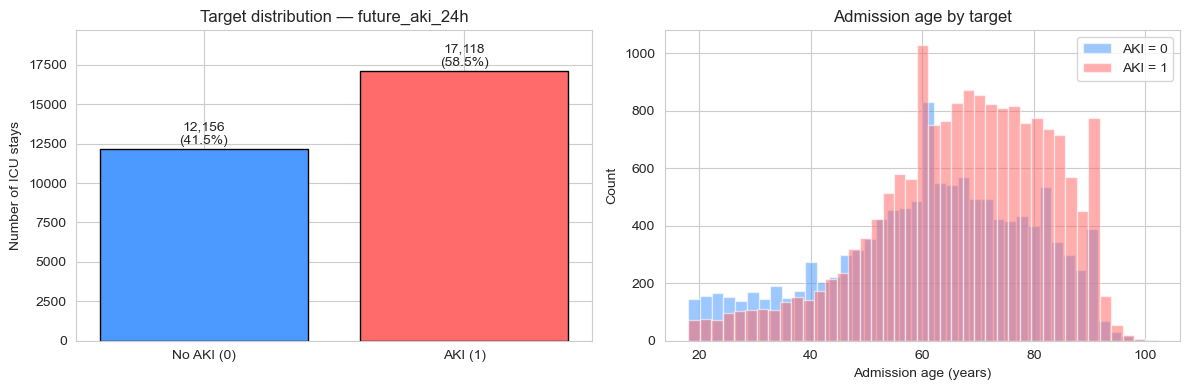

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: target class counts
counts = df_raw[target_col].value_counts().sort_index()
axes[0].bar(["No AKI (0)", "AKI (1)"], counts.values,
            color=["#4C9AFF", "#FF6B6B"], edgecolor="black")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f"{v:,}\n({v/len(df_raw):.1%})",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Number of ICU stays")
axes[0].set_title("Target distribution — future_aki_24h")
axes[0].set_ylim(0, counts.max() * 1.15)

# Right: age distribution by target
for lbl, color in [(0, "#4C9AFF"), (1, "#FF6B6B")]:
    axes[1].hist(df_raw.loc[df_raw[target_col] == lbl, "admission_age"],
                 bins=40, alpha=0.55, color=color,
                 label=f"AKI = {lbl}", edgecolor="white")
axes[1].set_xlabel("Admission age (years)")
axes[1].set_ylabel("Count")
axes[1].set_title("Admission age by target")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3  Figure 2 — comorbidity prevalence by target

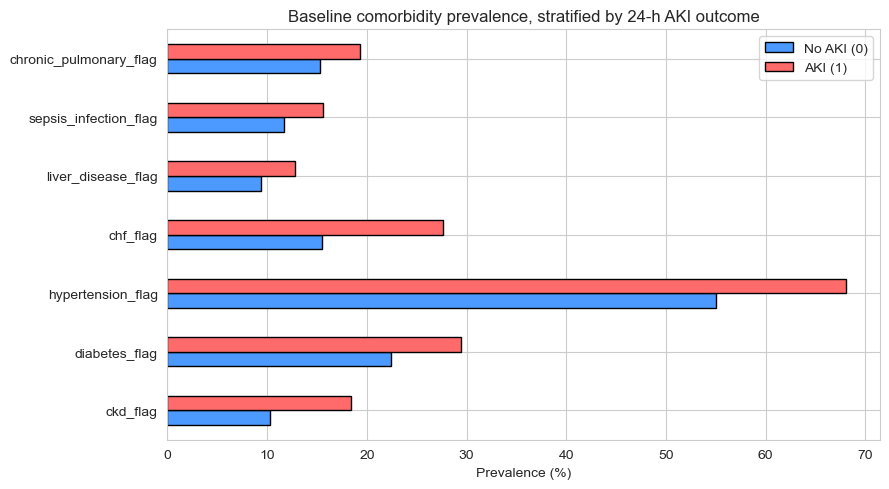

,No AKI (0),AKI (1)
ckd_flag,10.30,18.42
diabetes_flag,22.39,29.48
hypertension_flag,55.03,68.07
chf_flag,15.55,27.67
liver_disease_flag,9.35,12.75
sepsis_infection_flag,11.72,15.56
chronic_pulmonary_flag,15.33,19.36


In [6]:
comorb_cols = ["ckd_flag", "diabetes_flag", "hypertension_flag",
               "chf_flag", "liver_disease_flag",
               "sepsis_infection_flag", "chronic_pulmonary_flag"]

prev = (df_raw.groupby(target_col)[comorb_cols].mean().T * 100)
prev.columns = ["No AKI (0)", "AKI (1)"]

fig, ax = plt.subplots(figsize=(9, 5))
prev.plot(kind="barh", ax=ax, color=["#4C9AFF", "#FF6B6B"], edgecolor="black")
ax.set_xlabel("Prevalence (%)")
ax.set_title("Baseline comorbidity prevalence, stratified by 24-h AKI outcome")
ax.legend(title="")
plt.tight_layout()
plt.show()

prev.round(2)

### 3.4  Figure 3 — top missingness

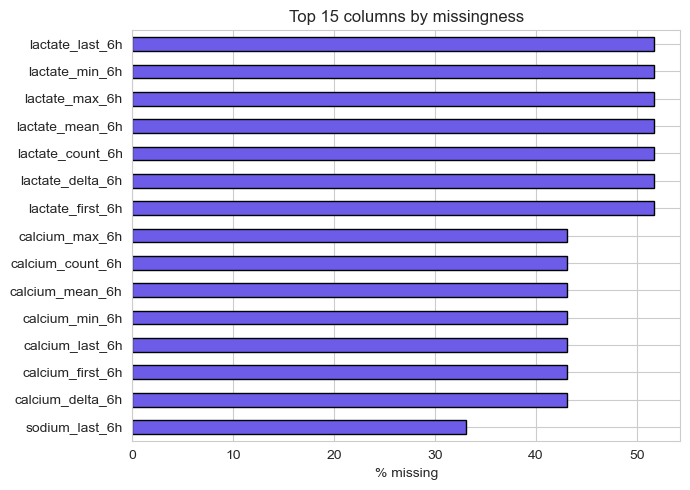

Columns with ≥ 40 % missingness:
lactate_first_6h    51.680672
lactate_delta_6h    51.680672
lactate_count_6h    51.680672
lactate_mean_6h     51.680672
lactate_max_6h      51.680672
lactate_min_6h      51.680672
lactate_last_6h     51.680672
calcium_delta_6h    43.021111
calcium_first_6h    43.021111
calcium_last_6h     43.021111
calcium_min_6h      43.021111
calcium_mean_6h     43.021111
calcium_count_6h    43.021111
calcium_max_6h      43.021111
dtype: float64


In [23]:
miss_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
top_missing = miss_pct[miss_pct > 0].head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top_missing.sort_values().plot(kind="barh", ax=ax,
                               color="#6C5CE7", edgecolor="black")
ax.set_xlabel("% missing")
ax.set_title("Top 15 columns by missingness")
plt.tight_layout()
plt.show()

print("Columns with ≥ 40 % missingness:")
print(miss_pct[miss_pct >= 40])

**EDA takeaways.**
- The cohort is roughly 58 % AKI-positive, so a naive “always predict 1” baseline would already reach ~58 % accuracy — AUROC and PR-AUC are more informative than accuracy here.
- The AKI group skews slightly older and has clearly higher prevalence of CKD, CHF and sepsis flags, which is consistent with clinical expectations.
- `lactate_*` features have ~51.7 % missingness and `calcium_*` ~43 %, reflecting that these labs are ordered selectively in the first 6 h of an ICU stay. Missingness is therefore likely **informative (MNAR)**, not random.

---
## Section 4: Data Preprocessing

### 4.1  Build the feature matrix (drop identifiers, timing, target)

In [8]:
drop_cols = id_cols + time_cols + [target_col]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()
y = df_raw[target_col].astype(int).copy()
groups = df_raw["subject_id"].copy()   # used later for subject-level split

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Feature matrix shape: {X.shape}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns:      {len(num_cols)}")

Feature matrix shape: (29274, 146)
Categorical columns (7): ['gender', 'race', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status']
Numeric columns:      139


### 4.2  Feature engineering

Following the clinical signals suggested in the dataset context, we derive a
small set of interpretable features that encode well-known AKI risk physiology:

| New feature | Formula | Rationale |
|---|---|---|
| `bun_creatinine_ratio_last_6h` | `bun_last_6h / creatinine_last_6h` | Pre-renal vs intrinsic AKI |
| `pulse_pressure_last_6h` | `sbp_last_6h − dbp_last_6h` | Haemodynamic instability |
| `shock_index_last_6h` | `heart_rate_last_6h / sbp_last_6h` | Occult shock |
| `urine_ml_per_kg_6h` | `urine_total_6h / weight_used_for_uo_norm` | Kidney output normalised |
| `creatinine_change_6h` | `creatinine_max_6h − creatinine_min_6h` | Acute Cr trajectory |

In [9]:
def _safe_div(num, den):
    out = num / den.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)

if {"bun_last_6h", "creatinine_last_6h"}.issubset(X.columns):
    X["bun_creatinine_ratio_last_6h"] = _safe_div(
        X["bun_last_6h"], X["creatinine_last_6h"])

if {"sbp_last_6h", "dbp_last_6h"}.issubset(X.columns):
    X["pulse_pressure_last_6h"] = X["sbp_last_6h"] - X["dbp_last_6h"]

if {"heart_rate_last_6h", "sbp_last_6h"}.issubset(X.columns):
    X["shock_index_last_6h"] = _safe_div(
        X["heart_rate_last_6h"], X["sbp_last_6h"])

if {"urine_total_6h", "weight_used_for_uo_norm"}.issubset(X.columns):
    X["urine_ml_per_kg_6h"] = _safe_div(
        X["urine_total_6h"], X["weight_used_for_uo_norm"])

if {"creatinine_max_6h", "creatinine_min_6h"}.issubset(X.columns):
    X["creatinine_change_6h"] = (
        X["creatinine_max_6h"] - X["creatinine_min_6h"])

new_feats = [
    "bun_creatinine_ratio_last_6h", "pulse_pressure_last_6h",
    "shock_index_last_6h", "urine_ml_per_kg_6h", "creatinine_change_6h",
]
print("Engineered features added:", [c for c in new_feats if c in X.columns])
print("Updated feature matrix shape:", X.shape)

Engineered features added: ['bun_creatinine_ratio_last_6h', 'pulse_pressure_last_6h', 'shock_index_last_6h', 'urine_ml_per_kg_6h', 'creatinine_change_6h']
Updated feature matrix shape: (29274, 151)


### 4.3  Encode categorical variables

Demographic/administrative categoricals are label-encoded so they can be used by both the linear and tree-based models without creating very wide one-hot matrices.

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    non_null = X[col].notna()
    # Build a fresh float64 column so the write works regardless of the
    # original dtype (object / str) in different pandas versions.
    encoded = pd.Series(np.nan, index=X.index, dtype="float64")
    if non_null.sum() > 0:
        encoded.loc[non_null] = le.fit_transform(
            X.loc[non_null, col].astype(str))
        label_encoders[col] = le
    X[col] = encoded

print("Categoricals encoded.")
X[cat_cols].head()

Categoricals encoded.


,gender,race,admission_type,admission_location,insurance,language,marital_status
0,0.0,28.0,5.0,5.0,2.0,1.0,1.0
1,0.0,7.0,6.0,2.0,1.0,1.0,1.0
2,0.0,22.0,7.0,6.0,1.0,1.0,2.0
3,0.0,28.0,5.0,7.0,2.0,1.0,1.0
4,0.0,28.0,6.0,8.0,1.0,1.0,2.0


### 4.4  Missingness: informative indicators + median imputation

Because several high-missingness features (`lactate_*`, `calcium_*`) are likely
**not missing at random**, we add a binary *missingness indicator* for each
numeric feature with ≥ 5 % missing values *before* imputing. We then impute the
original columns with the **training-set median** (fit below, after the split)
to avoid leakage.

In [11]:
missing_rate = X.isna().mean()
miss_ind_cols = missing_rate[(missing_rate >= 0.05)].index.tolist()
print(f"Adding {len(miss_ind_cols)} missingness indicators "
      f"(≥ 5% missing)")

for col in miss_ind_cols:
    X[f"{col}__isna"] = X[col].isna().astype(int)

print("Final feature matrix shape:", X.shape)

Adding 98 missingness indicators (≥ 5% missing)
Final feature matrix shape: (29274, 249)


---
## Section 5: Train / Validation / Test Split

Because the project spec requires splitting at the **subject level**, we use
`GroupShuffleSplit` with `subject_id` as the grouping variable. Even though the
current cleaned cohort has one row per subject, keeping the subject-level split
pattern makes the pipeline robust if the cohort is later expanded to include
multiple ICU stays per patient.

Split ratios:
- Train: 70 %
- Validation: 10 %
- Test: 20 %

Imputation (numeric median) is fit on the **training set only** and then
applied to validation and test sets to prevent leakage.

In [12]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20,
                         random_state=RANDOM_STATE)
idx_trainval, idx_test = next(gss1.split(X, y, groups))

X_trainval, y_trainval = X.iloc[idx_trainval], y.iloc[idx_trainval]
g_trainval = groups.iloc[idx_trainval]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125,  # 0.125*0.8 = 0.10
                         random_state=RANDOM_STATE)
idx_train_rel, idx_val_rel = next(gss2.split(X_trainval, y_trainval, g_trainval))

X_train = X_trainval.iloc[idx_train_rel]
y_train = y_trainval.iloc[idx_train_rel]
X_val   = X_trainval.iloc[idx_val_rel]
y_val   = y_trainval.iloc[idx_val_rel]
X_test  = X.iloc[idx_test]
y_test  = y.iloc[idx_test]

print(f"Train: {X_train.shape[0]:>6} rows ({y_train.mean():.2%} positive)")
print(f"Val:   {X_val.shape[0]:>6} rows ({y_val.mean():.2%} positive)")
print(f"Test:  {X_test.shape[0]:>6} rows ({y_test.mean():.2%} positive)")

# Sanity check: no subject overlap across splits
assert (set(groups.iloc[X_train.index]) &
        set(groups.iloc[X_val.index])) == set()
assert (set(groups.iloc[X_train.index]) &
        set(groups.iloc[X_test.index])) == set()
print("\nNo subject overlap between splits.")

Train:  20491 rows (58.49% positive)
Val:     2928 rows (58.40% positive)
Test:    5855 rows (58.45% positive)

No subject overlap between splits.


In [13]:
# Fit training-set medians and apply to all three splits
train_medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# Safety: any remaining NaN (e.g., all-NaN column in train) → 0
X_train = X_train.fillna(0)
X_val   = X_val.fillna(0)
X_test  = X_test.fillna(0)

print("Remaining NaNs — train:", X_train.isna().sum().sum(),
      "val:", X_val.isna().sum().sum(),
      "test:", X_test.isna().sum().sum())

Remaining NaNs — train: 0 val: 0 test: 0


---
## Section 6: Model 1 — Logistic Regression

The logistic-regression baseline is simple, linear and highly interpretable.
Numeric features are standardised (`StandardScaler`) because logistic
regression with an L2 penalty is sensitive to feature scale.

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_sc, y_train)
print("Logistic regression trained.")

Logistic regression trained.


---
## Section 7: Model 2 — Random Forest

The random forest uses 300 trees with default Gini splits. Unlike logistic
regression, it handles non-linear interactions natively and is invariant to
feature scaling, so we feed it the raw (imputed) matrix.

Random forest trained.


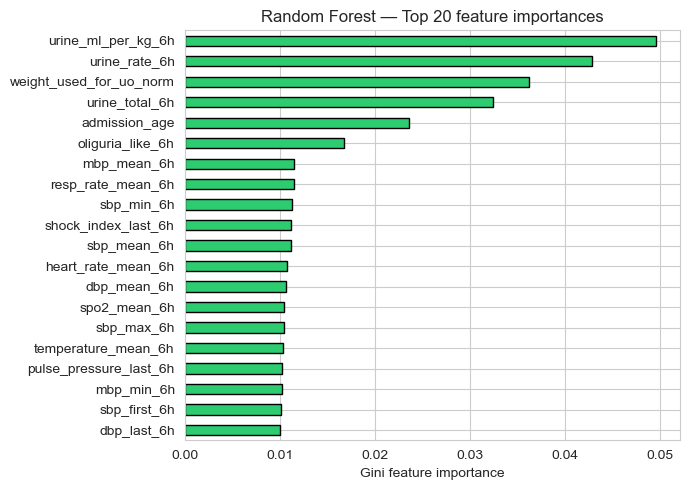

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print("Random forest trained.")

# Inspect top-20 features by RF importance — useful for interpretation
feat_imp = (pd.Series(rf.feature_importances_, index=X_train.columns)
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.head(20).sort_values().plot(kind="barh", ax=ax,
                                     color="#2ECC71", edgecolor="black")
ax.set_xlabel("Gini feature importance")
ax.set_title("Random Forest — Top 20 feature importances")
plt.tight_layout()
plt.show()

---
## Section 8: Model Evaluation — AUROC, PR-AUC, Calibration

We evaluate each model on **both** the held-out validation set and the
untouched test set, and report:
- Area under the ROC curve (AUROC)
- Area under the Precision-Recall curve (PR-AUC, equiv. to Average Precision)
- Brier score (lower = better calibrated)
- Calibration reliability curves

In [16]:
def evaluate_model(model, X_eval, y_eval, dataset_name, model_name,
                   scaler=None):
    X_use = scaler.transform(X_eval) if scaler is not None else X_eval
    y_prob = model.predict_proba(X_use)[:, 1]

    auroc = roc_auc_score(y_eval, y_prob)
    fpr, tpr, _ = roc_curve(y_eval, y_prob)

    pr_auc = average_precision_score(y_eval, y_prob)
    precision, recall, _ = precision_recall_curve(y_eval, y_prob)

    brier = brier_score_loss(y_eval, y_prob)
    prob_true, prob_pred = calibration_curve(y_eval, y_prob,
                                             n_bins=10, strategy="quantile")

    return {
        "model_name": model_name, "dataset": dataset_name,
        "auroc": auroc, "pr_auc": pr_auc, "brier": brier,
        "fpr": fpr, "tpr": tpr,
        "precision": precision, "recall": recall,
        "prob_true": prob_true, "prob_pred": prob_pred,
        "y_prob": y_prob, "y_true": y_eval.values,
    }

results = []
results.append(evaluate_model(logreg, X_val,  y_val,  "Validation", "LogReg", scaler))
results.append(evaluate_model(logreg, X_test, y_test, "Test",       "LogReg", scaler))
results.append(evaluate_model(rf,     X_val,  y_val,  "Validation", "RF"))
results.append(evaluate_model(rf,     X_test, y_test, "Test",       "RF"))

summary = (pd.DataFrame(results)
           [["model_name", "dataset", "auroc", "pr_auc", "brier"]]
           .round(4))
summary

,model_name,dataset,auroc,pr_auc,brier
0,LogReg,Validation,0.7297,0.7936,0.2049
1,LogReg,Test,0.7345,0.7960,0.2034
2,RF,Validation,0.7156,0.7801,0.2097
3,RF,Test,0.7288,0.7974,0.2053


### 8.1  ROC curves

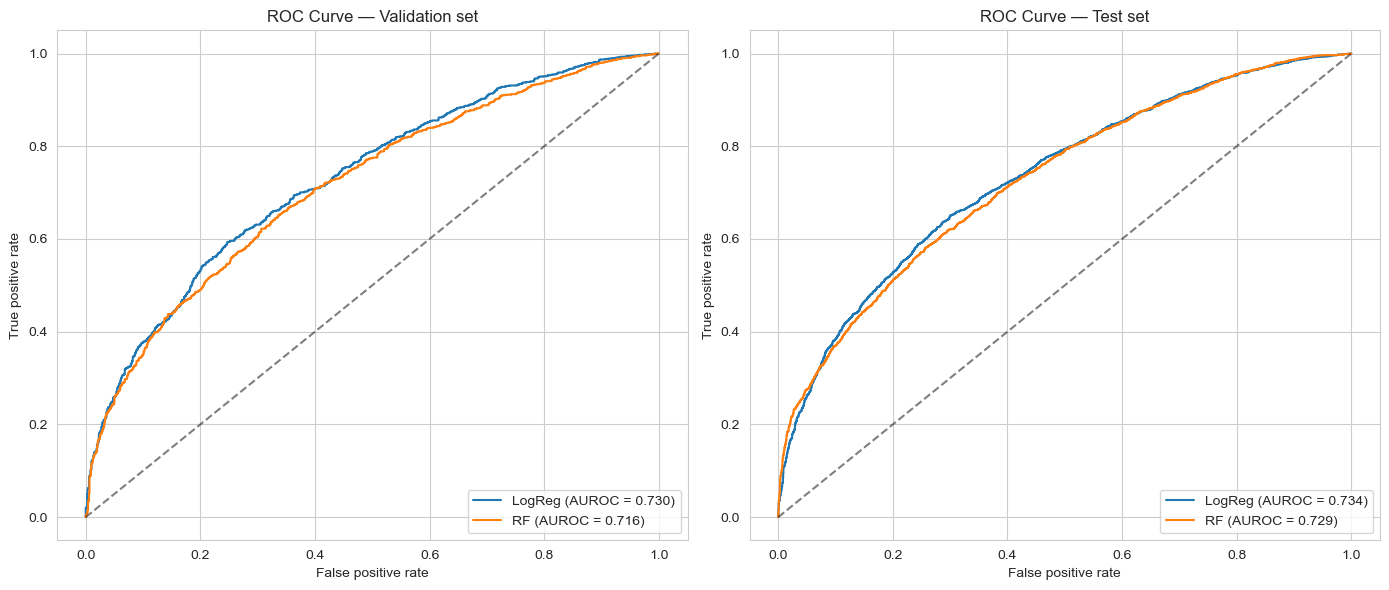

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["fpr"], r["tpr"],
                    label=f"{r['model_name']} (AUROC = {r['auroc']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC Curve — {dataset} set")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.2  Precision-Recall curves

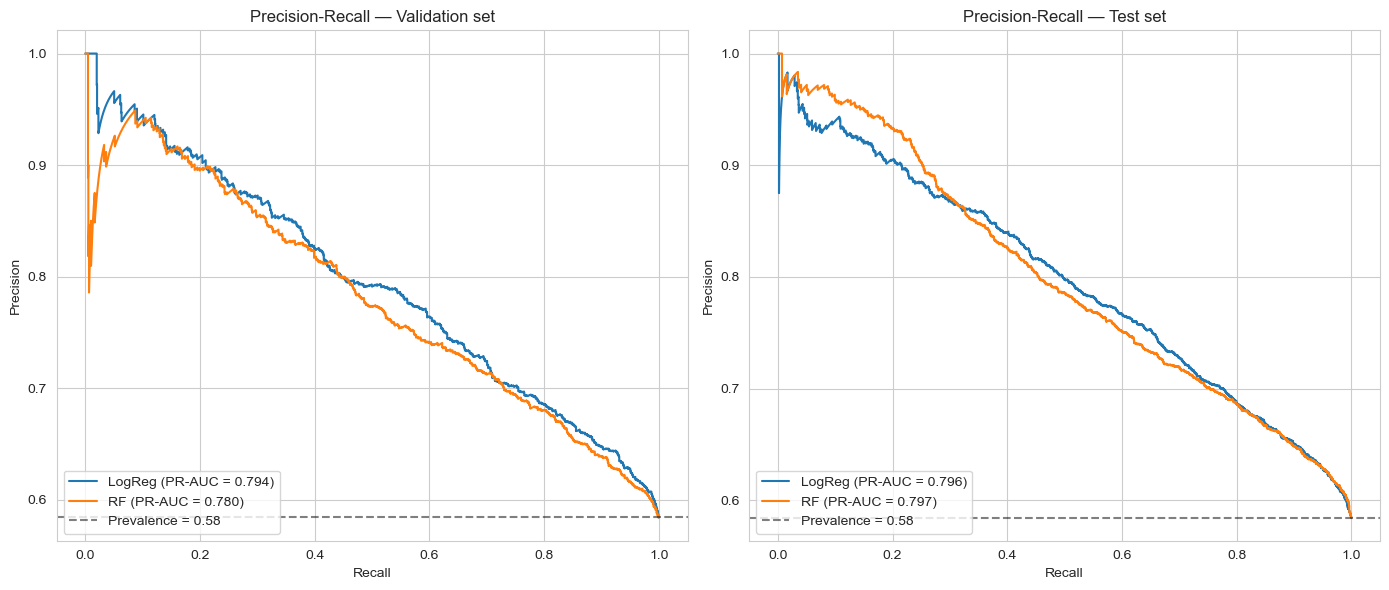

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["recall"], r["precision"],
                    label=f"{r['model_name']} (PR-AUC = {r['pr_auc']:.3f})")
    # baseline = positive rate
    pos_rate = (y_val.mean() if dataset == "Validation"
                else y_test.mean())
    ax.axhline(pos_rate, color="k", ls="--", alpha=0.5,
               label=f"Prevalence = {pos_rate:.2f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall — {dataset} set")
    ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### 8.3  Calibration curves

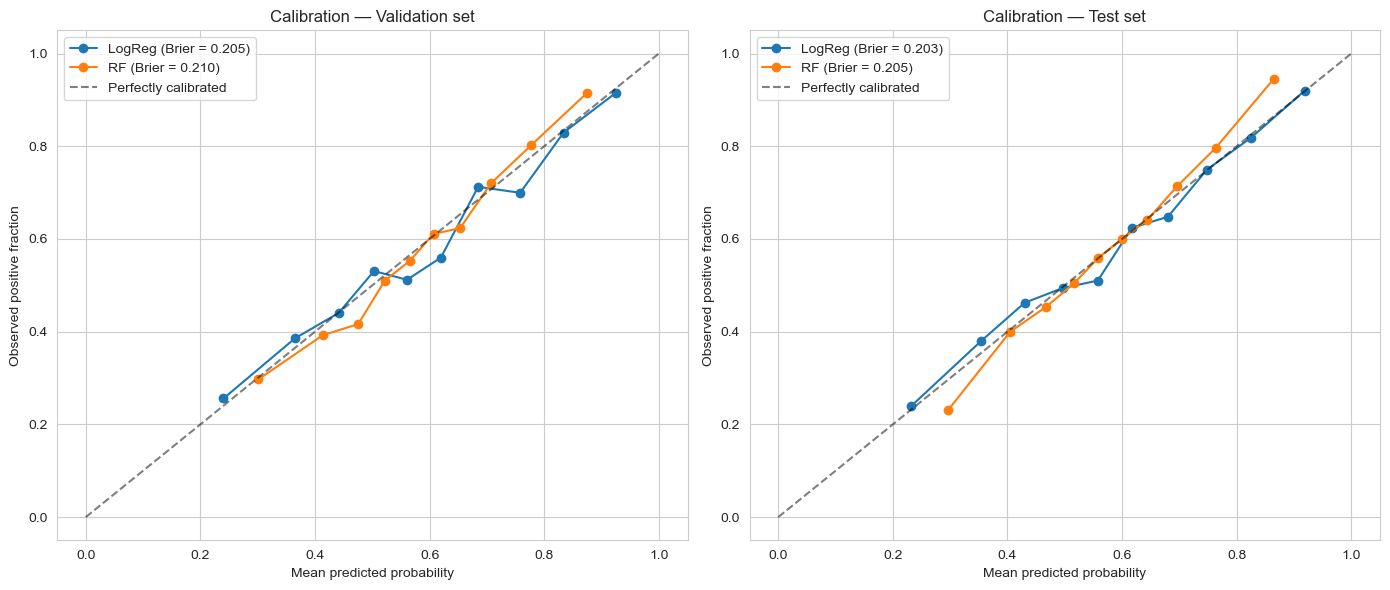

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["prob_pred"], r["prob_true"],
                    marker="o",
                    label=f"{r['model_name']} (Brier = {r['brier']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5,
            label="Perfectly calibrated")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive fraction")
    ax.set_title(f"Calibration — {dataset} set")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 8.4  Confusion matrices at the 0.5 threshold

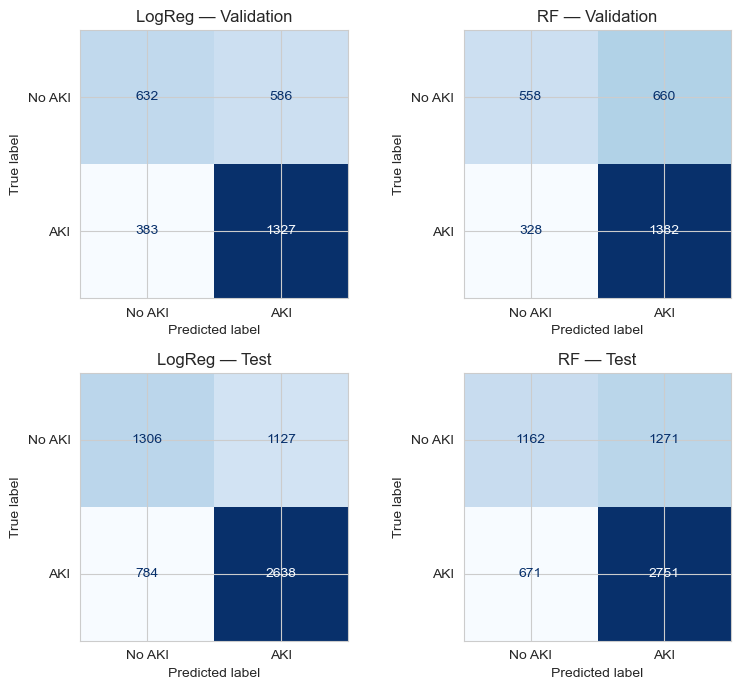

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for col, (mname, model, feats_scaler) in enumerate([
    ("LogReg", logreg, scaler),
    ("RF",     rf,     None),
]):
    for row, (dname, X_eval, y_eval) in enumerate([
        ("Validation", X_val,  y_val),
        ("Test",       X_test, y_test),
    ]):
        X_use = (feats_scaler.transform(X_eval)
                 if feats_scaler is not None else X_eval)
        y_pred = model.predict(X_use)
        cm = confusion_matrix(y_eval, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["No AKI", "AKI"]).plot(
            ax=axes[row, col], colorbar=False, cmap="Blues")
        axes[row, col].set_title(f"{mname} — {dname}")
plt.tight_layout()
plt.show()

### Interpreation of model performance & Comparison between splits and Models